## Hello! My name is David Finn and I will be performing a few data related tasks in this project. Firstly, I need to generate some more data, as my original dataset is pretty small! This is a mock Anheuser-Busch Data Analysis, and their data certainly have 1000's of times more data than this initial dataset:

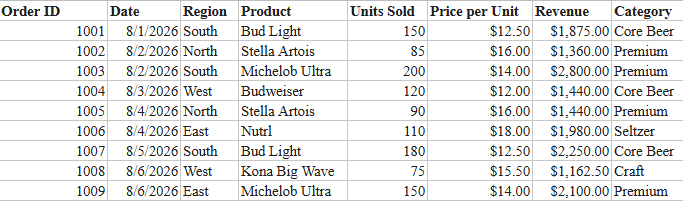

I am going to use python to generate many more rows of information, I would like to be somwhere around 100,000 entries. I will then use PythonDB to create my database in MySQL. After that, I will enter all of the information into said database, and then run queries and put together a presentation!

In [78]:
#install pandas for dataframes and numpy for nice math features
!pip install pandas
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
#bring the tools into this notebook so I can actually use them
import pandas as pd
import numpy as np

In [80]:
df = pd.read_csv("StarterBeerData.csv") #read a csv I placed in the same folder as this notebook file called StarterBeerData
beerData = df.iloc[:9, :8] #trim the dataset to only include the real information
beerData #display the entire dataframe

,Order ID,Date,Region,Product,Units Sold,Price per Unit,Revenue,Category
0,1001.0,8/1/2026,South,Bud Light,150.0,$12.50,"$1,875.00",Core Beer
1,1002.0,8/2/2026,North,Stella Artois,85.0,$16.00,"$1,360.00",Premium
2,1003.0,8/2/2026,South,Michelob Ultra,200.0,$14.00,"$2,800.00",Premium
3,1004.0,8/3/2026,West,Budweiser,120.0,$12.00,"$1,440.00",Core Beer
4,1005.0,8/4/2026,North,Stella Artois,90.0,$16.00,"$1,440.00",Premium
5,1006.0,8/4/2026,East,Nutrl,110.0,$18.00,"$1,980.00",Seltzer
6,1007.0,8/5/2026,South,Bud Light,180.0,$12.50,"$2,250.00",Core Beer
7,1008.0,8/6/2026,West,Kona Big Wave,75.0,$15.50,"$1,162.50",Craft
8,1009.0,8/6/2026,East,Michelob Ultra,150.0,$14.00,"$2,100.00",Premium


Now is a good time to mention I have a lookup table that I was using in excel. We can do something similar in this notebook. Here is what I have:

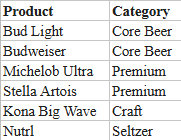

What I'm thinking is to create another dataframe object that contains the category information, and write some logic to determine category based on that. That way I could add to it in the future and it could easily handle it. 

In [81]:
categories = pd.read_csv("BeerCategories.csv") #import the category data into the dataframe
categories #display the entire dataframe

,Product,Category
0,Bud Light,Core Beer
1,Budweiser,Core Beer
2,Michelob Ultra,Premium
3,Stella Artois,Premium
4,Kona Big Wave,Craft
5,Nutrl,Seltzer


Okay, this is a pretty sad list of products that AB offers, so let's add some of the best ones.
I'm also going to make some tweaks as I go, like Mickeys being a core beer since they're a flagship item

In [82]:
categories.loc[categories['Product'] == 'Michelob Ultra', 'Category'] = 'Core Beer' #find where product is michelob ultra, set category to core beer
categories #display the dataframe
#this works because dataframe.loc checks for [row_indexer, col_indexer] which means what row? Okay found it, now what column? 

,Product,Category
0,Bud Light,Core Beer
1,Budweiser,Core Beer
2,Michelob Ultra,Core Beer
3,Stella Artois,Premium
4,Kona Big Wave,Craft
5,Nutrl,Seltzer


In [83]:
#establish the new categories to add
list_to_add = [
    ['Natural Light', 'Value'],
    ['Busch', 'Value'],
    ['Busch Light', 'Value'],
    ['Corona Extra', 'Premium'],
    ['Mango Cart', 'Craft'],
    ['Bud Light Seltzer', 'Seltzer']
]
#convert to dataframe to make the next step much easier
temp_df = pd.DataFrame(list_to_add, columns=categories.columns)
#join the current and new list together
categories = pd.concat([categories, temp_df], ignore_index=True)

In [84]:
#make sure it actually worked
categories

,Product,Category
0,Bud Light,Core Beer
1,Budweiser,Core Beer
2,Michelob Ultra,Core Beer
3,Stella Artois,Premium
4,Kona Big Wave,Craft
5,Nutrl,Seltzer
6,Natural Light,Value
7,Busch,Value
8,Busch Light,Value
9,Corona Extra,Premium


Okay, now that that is done, we can work on generating new data to work with. I'm going to make up some general pricing information using calculations to come up with a "reasonable" amount of money for each product.

Believe it or not, it is really difficult to find this information. This really takes away from the point of this project so I prompted Gemini 3.1 Pro "Can you rank these products by revenue in 2025, estiate is okay." This is essentially what it came up with.

1. Michelob Ultra
2. Bud Light
3. Corona Extra
4. Budweiser
5. Busch Light
6. Stella Artois
7. Natural Light
8. Busch
9. Nutrl
10. Kona Big Wave
11. Bud Light Seltzer
12. Mango Cart

This seems reasonable so I'll work with this. Also if you're wondering why Mango Cart is on this list, it's because it's my personal favorite product (:

What I'm going to do for the sake of simplicity is apply a random value within a specified range, and apply a weight to that calculation depending on the position of the product on the list. I think the top range will be 250 units sold, and the bottom of the range will be 50 units.

For this it makes sense to order the products by "rank", and I also need to include a cost per unit, and generate units each day. 

So to break all of this down again, I will be generating 30 days of sales information, where each product has a number of units sold based on how popular of an item they are (their rank), and that will apply to their cost per unit to produce a revenue for that product, for that day. This will give me a months worth of information to work with, which we could scale up to include an entire years worth of information. 

In [85]:
#let's add a rank column
categories['Rank'] = [2, 4, 1, 6, 10, 9, 7, 8, 5, 3, 12, 11]
#display to check
categories

,Product,Category,Rank
0,Bud Light,Core Beer,2
1,Budweiser,Core Beer,4
2,Michelob Ultra,Core Beer,1
3,Stella Artois,Premium,6
4,Kona Big Wave,Craft,10
5,Nutrl,Seltzer,9
6,Natural Light,Value,7
7,Busch,Value,8
8,Busch Light,Value,5
9,Corona Extra,Premium,3


In [86]:
#now let's order it by rank
categories = categories.sort_values(by='Rank').reset_index(drop=True)
categories

,Product,Category,Rank
0,Michelob Ultra,Core Beer,1
1,Bud Light,Core Beer,2
2,Corona Extra,Premium,3
3,Budweiser,Core Beer,4
4,Busch Light,Value,5
5,Stella Artois,Premium,6
6,Natural Light,Value,7
7,Busch,Value,8
8,Nutrl,Seltzer,9
9,Kona Big Wave,Craft,10


Now we have our ranked list of products. 

For the next steps to make sense, I've realized I need to establish the cost per unit for each of these products.

In [87]:
#prices are based on the initial example estimate, plus estimations to stay consistent
categories['Cost Per Unit'] = [14.00, 12.50, 14.00, 12.00, 12.00, 16.00, 11.00, 11.50, 18.00, 15.50, 17.00, 13.00]
categories

,Product,Category,Rank,Cost Per Unit
0,Michelob Ultra,Core Beer,1,14.0
1,Bud Light,Core Beer,2,12.5
2,Corona Extra,Premium,3,14.0
3,Budweiser,Core Beer,4,12.0
4,Busch Light,Value,5,12.0
5,Stella Artois,Premium,6,16.0
6,Natural Light,Value,7,11.0
7,Busch,Value,8,11.5
8,Nutrl,Seltzer,9,18.0
9,Kona Big Wave,Craft,10,15.5


I want the results of this project to be reproducible so I will use a seed for random number generation. To break this down one more time, for every day from 8/7/2026 to 9/7/2026 we want sales information on that day for each of the 4 regions, for each of the products. So each day will have 48 entries into the dataset. This makes sense to me because there are going to be sales in every region in a real model. 

As far as calculating the units sold, followed by revenue, I am generating 12 random numbers between 50 and 250. I will order the numbers in descending order, and apply them to the products from 1-12. So for example we get 250, 225, 200 and they will go to 1, 2, 3. This ensures that the lowest ranked products intuitively show the least products sold, because that's why they're the lowest rank!

In [88]:
#set the seed to 42 for no specific reason, could set it something like ctime in c++ for a random number every time.
np.random.seed(42)
regions = ['North', 'South', 'East', 'West']

#redundancy to ensure products are in the right order
lookup = categories.sort_values('Rank').reset_index(drop=True)

#get a list of dates from 7th to 7th, days in specific
dates = pd.date_range(start='2026-08-07', end='2026-09-07', freq='D') 

#empty list to recieve records
records = []

#orderID to increment for each record
order_id = 1 #starting this at 1 instead of continuing the example data. 

for date in dates:
    for region in regions:
        #12 random numbers from 50-250
        random_units = np.random.randint(50, 251, size=len(lookup))
        sorted_units = np.sort(random_units)[::-1] #descending order

        for i, units in enumerate(sorted_units):
            rank = i+1
            
            #starts at rank=1, so looks up the row where rank is rank(1), then go to the first column which contains the product name
            product_row = lookup.loc[lookup['Rank'] == rank].iloc[0] 
            price = product_row['Cost Per Unit'] #in that row, price is cost per unit
            revenue = round(units * price, 2) #calculate revenue, round to 2 decimal places

            #add the following information into the records list
            records.append({
                'Order ID': order_id, #Order ID
                'Date': date.strftime('%#m/%#d/%Y'), #looks like an alien language but properly formats the dates to be like the example table
                'Region': region, #Region
                'Product': product_row['Product'], #Product name
                'Units Sold': units, #Generated units sold
                'Price per Unit': price, #Price
                'Revenue': revenue, #Calculated Revenue
                'Category': product_row['Category'] #Category
            })
            order_id += 1 #increment the order_id

#take that list, and turn it into a dataframe
generated_data = pd.DataFrame(records)

Now that the bulk of this is done, we can look through the data to make sure things seem okay.

In [89]:
#Get 50 rows at random
generated_data.sample(50)

,Order ID,Date,Region,Product,Units Sold,Price per Unit,Revenue,Category
612,613,8/19/2026,West,Michelob Ultra,236,14.0,3304.0,Core Beer
468,469,8/16/2026,West,Michelob Ultra,207,14.0,2898.0,Core Beer
1357,1358,9/4/2026,South,Bud Light,215,12.5,2687.5,Core Beer
586,587,8/19/2026,North,Bud Light Seltzer,107,17.0,1819.0,Seltzer
1047,1048,8/28/2026,West,Budweiser,183,12.0,2196.0,Core Beer
1195,1196,8/31/2026,West,Busch,115,11.5,1322.5,Value
602,603,8/19/2026,East,Corona Extra,201,14.0,2814.0,Premium
1280,1281,9/2/2026,East,Nutrl,164,18.0,2952.0,Seltzer
1091,1092,8/29/2026,East,Mango Cart,52,13.0,676.0,Craft
122,123,8/9/2026,East,Corona Extra,211,14.0,2954.0,Premium


I'm sure somwwhere in your sample there was an example of Mango Cart having a bad day. While we're at it, let's see if that was the lowest revenue producing item in this dataset.

In [ ]:
#take the column 'Revenue' in generated_date, call idxmin() to receice the index of the lowest value in that column, and pass that to .loc to get
#the full row that it belongs to. Call that in display() to show the full dataframe looking row.
display(generated_data.loc[[generated_data['Revenue'].idxmin()]])

You may surpsied that it had an even worse performance, however given the nature of the algorithm, it was bound to happen. Because the lowest value of the 12 generated values is always Mango Cart, it was bound to have atleast 1 day where it sold the minimum of 50 units. In a real dataset, this might be possible but is probably not guaranteed to be the lowest ranked item of the list. For example, what if the east just hates Bud Light Seltzer and sells even less than Mango Cart. 

At this point, we have the data, so I am actually going to ditch the original exmaple data, as the goal was to generate a full dataset to play with. That initial example was given to me by Google Gemini. (If you're wondering why I was using Gemini, it's becuase I received a full year subscription to it's pro model for free from Handshake. I've still found that the free version of Claude far outperforms Gemini pro with programming and technical assistance.)

In [90]:
beerData = generated_data

# MySQL 

Now that I have my data, I would like to upload it into a database. I will be using mysql-connector-python to accomplish this. 

In [91]:
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Now I am going to create the database in my command prompt ( I am on Windows )

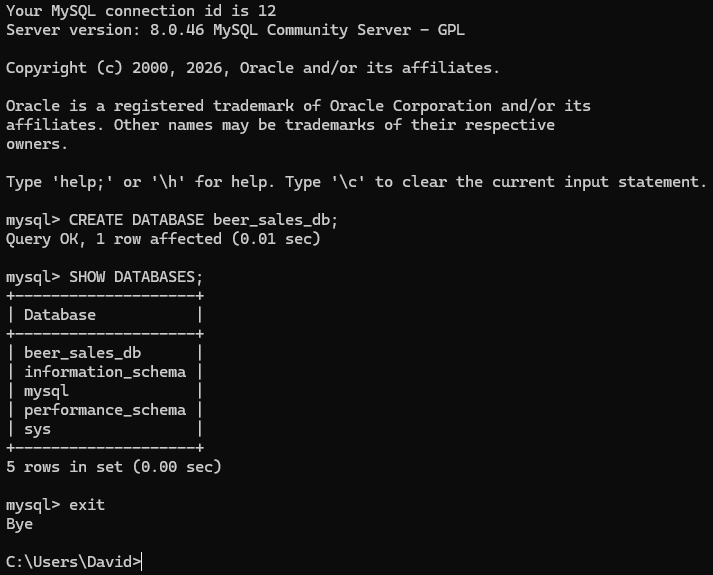

As you can see, I ran CREATE DATABASE beer_sales_db; and it displayed after commanding SHOW DATABASES;

Now I need to connect to it within this python session using the mysql connector

## All of the MySQL code is commented out because you would need to download MySQL, setup and environment, and set your password to what I have. So to save you the headache, it is commented out.

In [92]:
'''
import mysql.connector

#establish the connection to the database
conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = 'ExamplePassword#123!',
    database='beer_sales_db'
)

#establish a cursor which essentially lets me tell it what to do
cursor = conn.cursor() 
'''

"\nimport mysql.connector\n\n#establish the connection to the database\nconn = mysql.connector.connect(\n    host = 'localhost',\n    user = 'root',\n    password = 'ExamplePassword#123!',\n    database='beer_sales_db'\n)\n\n#establish a cursor which essentially lets me tell it what to do\ncursor = conn.cursor() \n"

Now that I have established the connection and cursor, I can start entering the data. This is where python shines for data analysis / data science

In [93]:
#actually have to re format the date to a usable format for MySQL
beerData['Date'] = pd.to_datetime(beerData['Date']).dt.strftime('%Y-%m-%d')

In [94]:
'''
create_table_query = """
CREATE TABLE IF NOT EXISTS beer_sales (
    `Order ID` INT PRIMARY KEY,
    `Date` DATE,
    `Region` VARCHAR(10),
    `Product` VARCHAR(50),
    `Units Sold` INT,
    `Price per Unit` FLOAT,
    `Revenue` FLOAT,
    `Category` VARCHAR(20)
)
"""
cursor.execute(create_table_query)
conn.commit()

insert_query = """
INSERT INTO beer_sales
(`Order ID`, `Date`, `Region`, `Product`, `Units Sold`, `Price per Unit`, `Revenue`, `Category`)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
"""

data_tuples = list(beerData.itertuples(index=False, name=None))

cursor.executemany(insert_query, data_tuples)
conn.commit()

print(f"{cursor.rowcount} rows inserted successfully.")

cursor.close()
conn.close()

commenting this out so I don't accidentally run it again
'''

'\ncreate_table_query = """\nCREATE TABLE IF NOT EXISTS beer_sales (\n    `Order ID` INT PRIMARY KEY,\n    `Date` DATE,\n    `Region` VARCHAR(10),\n    `Product` VARCHAR(50),\n    `Units Sold` INT,\n    `Price per Unit` FLOAT,\n    `Revenue` FLOAT,\n    `Category` VARCHAR(20)\n)\n"""\ncursor.execute(create_table_query)\nconn.commit()\n\ninsert_query = """\nINSERT INTO beer_sales\n(`Order ID`, `Date`, `Region`, `Product`, `Units Sold`, `Price per Unit`, `Revenue`, `Category`)\nVALUES (%s, %s, %s, %s, %s, %s, %s, %s)\n"""\n\ndata_tuples = list(beerData.itertuples(index=False, name=None))\n\ncursor.executemany(insert_query, data_tuples)\nconn.commit()\n\nprint(f"{cursor.rowcount} rows inserted successfully.")\n\ncursor.close()\nconn.close()\n\ncommenting this out so I don\'t accidentally run it again\n'

## (It showed 1536 rows inserted successfully) 

Now that's what we want to see. Inserted all of the rows into the table, now real quick I want to make sure it's in there by running a query.


In [95]:
'''
#re-establish the connection
conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = 'ExamplePassword#123!',
    database='beer_sales_db'
)

#open up the cursor
cursor = conn.cursor() 

#create the query
query = "SELECT * FROM beer_sales WHERE Revenue > 3000"

#execute the query
cursor.execute(query)

#get the results from the cursor and bring them into this notebook
results = cursor.fetchall()

#get the columns that should be set for the empty dataframe to take in alongside the results
columns = [desc[0] for desc in cursor.description]

#capture results with proper format and put into a dataframe
results_df = pd.DataFrame(results, columns=columns)

#close up the connection
cursor.close()
conn.close()

#display the dataframe
results_df
'''

'\n#re-establish the connection\nconn = mysql.connector.connect(\n    host = \'localhost\',\n    user = \'root\',\n    password = \'ExamplePassword#123!\',\n    database=\'beer_sales_db\'\n)\n\n#open up the cursor\ncursor = conn.cursor() \n\n#create the query\nquery = "SELECT * FROM beer_sales WHERE Revenue > 3000"\n\n#execute the query\ncursor.execute(query)\n\n#get the results from the cursor and bring them into this notebook\nresults = cursor.fetchall()\n\n#get the columns that should be set for the empty dataframe to take in alongside the results\ncolumns = [desc[0] for desc in cursor.description]\n\n#capture results with proper format and put into a dataframe\nresults_df = pd.DataFrame(results, columns=columns)\n\n#close up the connection\ncursor.close()\nconn.close()\n\n#display the dataframe\nresults_df\n'

## Below is the dataframe that I captured with the series of statements above.

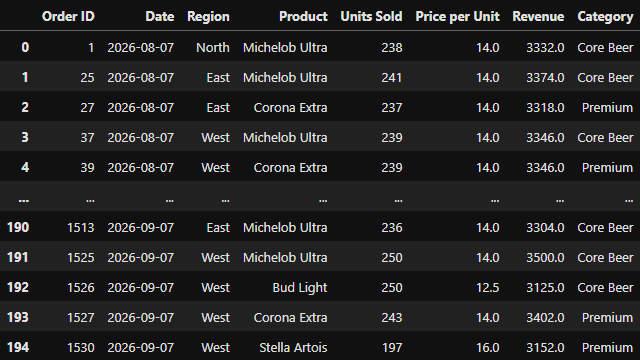

# Bad News
--------

So I don't have the desktop version of excel, and it's required to connect MySQL to it. That being said, I'm just going to export the data as a csv and bring it over to excel to work with. In a work environment, I would certainly have desktop access and be able to pull from the database directly. 

In [96]:
beerData.to_csv('beer_sales.csv', index=False)

Now I have saved it to the Jupyter folder and can bring it over to excel.

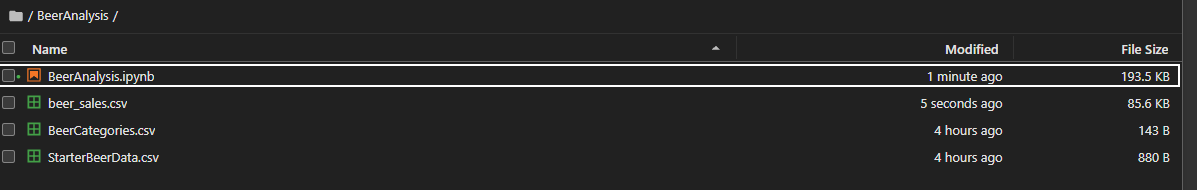

After bringing the CSV into Excel, I quickly formated Price per Unit and Revenue to Currency, and formatted the date to my liking.

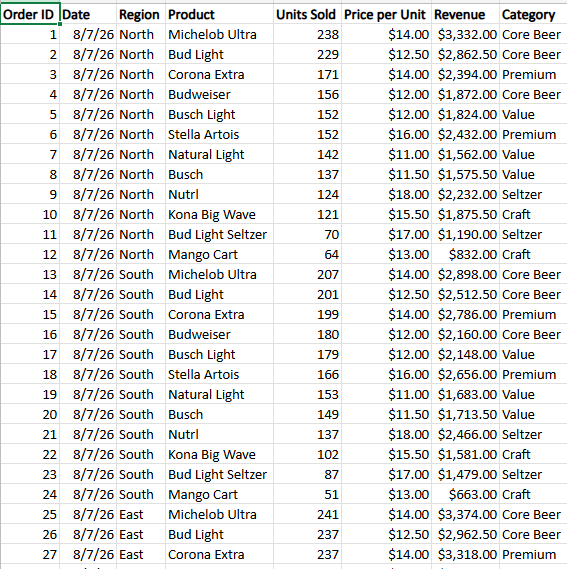

Next I am going to turn this into a pivot table and derive some insights!

The first table I went with as Total units sold and Total revenue per product, as I think this is some pretty important stuff. Additionally, I'd like to see if the ranken stayed the same. 

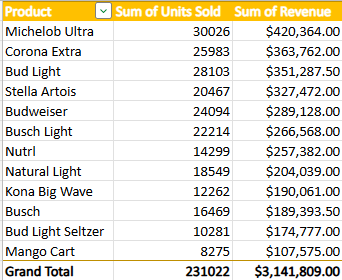

To my surpise, Corona outsold Bud Light! We can see that while Bud Light sold more units, corona being at the higher price point produced more revenue. This is really interesting to see! Sadly Mango Cart is last place, but was the inspriation behind the color choice of the pivot table, because it's the winner in my heart ;)

I would like to see this in a couple of charts instead of a pool of numbers.

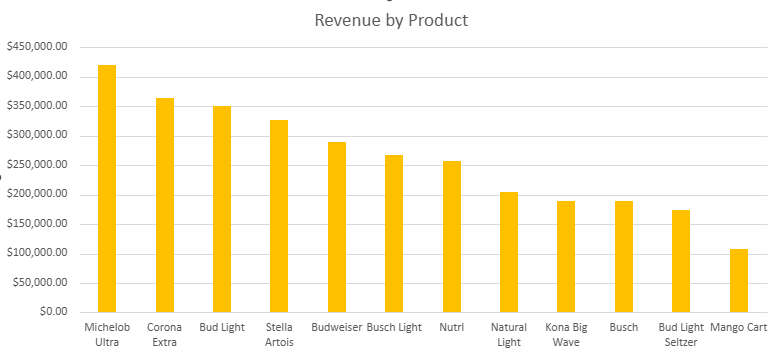

Ah, much better. Now everyone can see that Michelob Ultra sells best, followed by Corona Extra and Bud Light. Whether or not this is consistent with reality is not of my concern.

# Summary

### This project was really fun for me. I started it around 5:30 PM 8/25/2026 and at the time of writing this it is 10:25 PM 8/25/2026. I really wanted to exercise my skills in Python, SQL, and Excel and I think this turned out alright. I want to clear some things up for this. 
---------------
## 1. Yes I worked alongside AI to help me work through this project. I want to be very clear that I did not use as a solution maker, I used it as a mentor to explain small things to me along the way, or remind me of something that I forgot for the 1000th time. 
## 2. This information is completely made up, and is no way indicative of reality. I based pricing off of a hunch, and randomly generated the sales data.
## 3. I am still learning. I wanted to do this project for that reason specifically. I just hope this project can give whomever is reading this a glimpse into my mind and help them see my ability work with data, and how I think about it. 

# Thank you so much for checking out my work!

#### If you're reading this, send me a mango emoji on LinkedIn (: 

## https://www.linkedin.com/in/david-m-finn/